<a href="https://colab.research.google.com/github/leonardshindikwa11-tech/business-web/blob/main/model_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install and Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')


Upload and load data

In [3]:
file_path = r"/content/drive/MyDrive/Tanzania_Water_Quality_All_Regions.xlsx"

In [4]:
# Cell 3 - Load data
df = pd.read_excel(file_path, sheet_name='RAW DATA TANZANIA')

print("Shape ya data:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape ya data: (260, 17)

Columns:
['S/N', 'Unnamed: 1', 'Unnamed: 2', 'Coordinates_Lat', 'Coordinates_Lon', 'Region/Zone', 'NAME', 'PH', 'NITRATE (PPM)', 'FLUORIDE (PPM)', 'TOTAL HARDNESS (mg/L)', 'CALCIUM Ca2+(mg/L)', 'MAGNESIUM Mg2+(mg/L)', '(HCO3-) (mg/L)', 'CONDUCTIVITY (µS/cm)', 'TDS (PPM)', 'TURBIDITY (NTU)']


,S/N,Unnamed: 1,Unnamed: 2,Coordinates_Lat,Coordinates_Lon,Region/Zone,NAME,PH,NITRATE (PPM),FLUORIDE (PPM),TOTAL HARDNESS (mg/L),CALCIUM Ca2+(mg/L),MAGNESIUM Mg2+(mg/L),(HCO3-) (mg/L),CONDUCTIVITY (µS/cm),TDS (PPM),TURBIDITY (NTU)
0,1,1,1,S03°07.500',E036°54.060',ARUSHA-ZONE,ARUSHA-STATION-1,8.37,37.9,3.59,171.48,35.790,19.940,145.2,1922.5,1176.7,1.91
1,2,2,2,S02°31.800',E036°39.900',ARUSHA-ZONE,ARUSHA-STATION-2,7.54,15.0,3.78,220.40,61.428,16.274,148.3,1240.7,743.9,7.14
2,3,3,3,S03°12.480',E035°43.980',ARUSHA-ZONE,ARUSHA-STATION-3,7.93,48.2,3.90,289.70,83.683,19.607,150.2,1936.6,1050.0,3.86
3,4,4,4,S02°33.060',E036°55.860',ARUSHA-ZONE,ARUSHA-STATION-4,8.49,21.8,3.18,345.80,91.991,28.193,189.8,1689.4,886.0,41.01
4,5,5,5,S03°14.460',E036°19.500',ARUSHA-ZONE,ARUSHA-STATION-5,7.70,33.6,6.33,181.00,62.524,6.041,146.6,2666.9,1697.0,27.31


CHECK FOR DUPLICATED DATA

In [5]:

print("="*50)
print("1. Kuangalia Duplicates")
print("="*50)

# Angalia idadi ya rows zilizojirudia (duplicates)
duplicates_count = df.duplicated().sum()
print(f"Idadi ya rows zilizojirudia (duplicates): {duplicates_count}")

if duplicates_count > 0:
    print("\nRows zilizojirudia:")
    print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))

    # Ondoa duplicates (hifadhi ya kwanza)
    df = df.drop_duplicates()
    print(f"\nBaada ya kuondoa duplicates, shape mpya: {df.shape}")
else:
    print("Hakuna duplicates! Data ni safi.")

1. Kuangalia Duplicates
Idadi ya rows zilizojirudia (duplicates): 0
Hakuna duplicates! Data ni safi.


Data Cleaning and Feature Engineering

In [6]:
# Ondoa columns zisizohitajika
df_clean = df.drop(columns=['S/N', 'Unnamed: 1', 'Unnamed: 2', 'NAME'], errors='ignore')

# Function ya kubadilisha coordinates (DMS → Decimal Degrees)
def dms_to_decimal(coord):
    try:
        direction = coord[0]
        degrees = float(coord[1:3])
        minutes = float(coord[4:10])
        decimal = degrees + minutes/60
        if direction in ['S', 'W']:
            decimal = -decimal
        return decimal
    except:
        return np.nan

df_clean['Lat'] = df_clean['Coordinates_Lat'].apply(dms_to_decimal)
df_clean['Lon'] = df_clean['Coordinates_Lon'].apply(dms_to_decimal)

# Encode Region
le = LabelEncoder()
df_clean['Region_encoded'] = le.fit_transform(df_clean['Region/Zone'])

print("Data baada ya cleaning:")
print(df_clean[['Region/Zone', 'Region_encoded', 'Lat', 'Lon', 'PH']].head())
print("\nMissing values:", df_clean.isnull().sum().sum())

Data baada ya cleaning:
   Region/Zone  Region_encoded    Lat  Lon    PH
0  ARUSHA-ZONE               0 -3.125  NaN  8.37
1  ARUSHA-ZONE               0 -2.530  NaN  7.54
2  ARUSHA-ZONE               0 -3.208  NaN  7.93
3  ARUSHA-ZONE               0 -2.551  NaN  8.49
4  ARUSHA-ZONE               0 -3.241  NaN  7.70

Missing values: 260


Check missing Values

In [7]:
missing = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percentage
})

display(
    missing_table.sort_values(
        "Percentage (%)",
        ascending=False
    )
)

,Missing Values,Percentage (%)
S/N,0,0.0
Unnamed: 1,0,0.0
Unnamed: 2,0,0.0
Coordinates_Lat,0,0.0
Coordinates_Lon,0,0.0
Region/Zone,0,0.0
NAME,0,0.0
PH,0,0.0
NITRATE (PPM),0,0.0
FLUORIDE (PPM),0,0.0


Data Cleaning & Feature Selection

In [8]:
# Ondoa columns zisizohitajika (identifiers)
cols_to_drop = ['S/N', 'Unnamed: 1', 'Unnamed: 2', 'Coordinates_Lat',
                'Coordinates_Lon', 'NAME']

df_clean = df.drop(columns=cols_to_drop)

print("Null values:")
print(df_clean.isnull().sum())

print("\nData baada ya kusafisha:")
df_clean.head()

Null values:
Region/Zone              0
PH                       0
NITRATE (PPM)            0
FLUORIDE (PPM)           0
TOTAL HARDNESS (mg/L)    0
CALCIUM Ca2+(mg/L)       0
MAGNESIUM Mg2+(mg/L)     0
(HCO3-) (mg/L)           0
CONDUCTIVITY (µS/cm)     0
TDS (PPM)                0
TURBIDITY (NTU)          0
dtype: int64

Data baada ya kusafisha:


,Region/Zone,PH,NITRATE (PPM),FLUORIDE (PPM),TOTAL HARDNESS (mg/L),CALCIUM Ca2+(mg/L),MAGNESIUM Mg2+(mg/L),(HCO3-) (mg/L),CONDUCTIVITY (µS/cm),TDS (PPM),TURBIDITY (NTU)
0,ARUSHA-ZONE,8.37,37.9,3.59,171.48,35.790,19.940,145.2,1922.5,1176.7,1.91
1,ARUSHA-ZONE,7.54,15.0,3.78,220.40,61.428,16.274,148.3,1240.7,743.9,7.14
2,ARUSHA-ZONE,7.93,48.2,3.90,289.70,83.683,19.607,150.2,1936.6,1050.0,3.86
3,ARUSHA-ZONE,8.49,21.8,3.18,345.80,91.991,28.193,189.8,1689.4,886.0,41.01
4,ARUSHA-ZONE,7.70,33.6,6.33,181.00,62.524,6.041,146.6,2666.9,1697.0,27.31


Encode Region (Categorical Feature)

In [9]:
# STEP 4: Encode Region/Zone
le = LabelEncoder()
df_clean['Region_Encoded'] = le.fit_transform(df_clean['Region/Zone'])

# Hifadhi mapping kwa baadaye
region_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Region Encoding:")
print(region_mapping)

# Ondoa column ya asili ya Region
df_clean = df_clean.drop(columns=['Region/Zone'])
df_clean.head()

Region Encoding:
{'ARUSHA-ZONE': np.int64(0), 'DAR ES SALAAM-ZONE': np.int64(1), 'DODOMA-ZONE': np.int64(2), 'GEITA-ZONE': np.int64(3), 'IRINGA-ZONE': np.int64(4), 'KAGERA-ZONE': np.int64(5), 'KATAVI-ZONE': np.int64(6), 'KIGOMA-ZONE': np.int64(7), 'KILIMANJARO-ZONE': np.int64(8), 'LINDI-ZONE': np.int64(9), 'MANYARA-ZONE': np.int64(10), 'MARA-ZONE': np.int64(11), 'MBEYA-ZONE': np.int64(12), 'MOROGORO-ZONE': np.int64(13), 'MTWARA-ZONE': np.int64(14), 'MWANZA-ZONE': np.int64(15), 'NJOMBE-ZONE': np.int64(16), 'PWANI-ZONE': np.int64(17), 'RUKWA-ZONE': np.int64(18), 'RUVUMA-ZONE': np.int64(19), 'SHINYANGA-ZONE': np.int64(20), 'SIMIYU-ZONE': np.int64(21), 'SINGIDA-ZONE': np.int64(22), 'SONGWE-ZONE': np.int64(23), 'TABORA-ZONE': np.int64(24), 'TANGA-ZONE': np.int64(25)}


,PH,NITRATE (PPM),FLUORIDE (PPM),TOTAL HARDNESS (mg/L),CALCIUM Ca2+(mg/L),MAGNESIUM Mg2+(mg/L),(HCO3-) (mg/L),CONDUCTIVITY (µS/cm),TDS (PPM),TURBIDITY (NTU),Region_Encoded
0,8.37,37.9,3.59,171.48,35.790,19.940,145.2,1922.5,1176.7,1.91,0
1,7.54,15.0,3.78,220.40,61.428,16.274,148.3,1240.7,743.9,7.14,0
2,7.93,48.2,3.90,289.70,83.683,19.607,150.2,1936.6,1050.0,3.86,0
3,8.49,21.8,3.18,345.80,91.991,28.193,189.8,1689.4,886.0,41.01,0
4,7.70,33.6,6.33,181.00,62.524,6.041,146.6,2666.9,1697.0,27.31,0


In [10]:
df.columns

Index(['S/N', 'Unnamed: 1', 'Unnamed: 2', 'Coordinates_Lat', 'Coordinates_Lon',
       'Region/Zone', 'NAME', 'PH', 'NITRATE (PPM)', 'FLUORIDE (PPM)',
       'TOTAL HARDNESS (mg/L)', 'CALCIUM Ca2+(mg/L)', 'MAGNESIUM Mg2+(mg/L)',
       '(HCO3-) (mg/L)', 'CONDUCTIVITY (µS/cm)', 'TDS (PPM)',
       'TURBIDITY (NTU)'],
      dtype='object')

Define Features (X) and Targets (y)
Python

In [11]:
# Targets (tunachotaka kutabiri)
target_cols = ['PH', 'TOTAL HARDNESS (mg/L)', 'CONDUCTIVITY (µS/cm)']

# Features (vigezo vya kuingiza)
feature_cols = [col for col in df_clean.columns if col not in target_cols]

X = df_clean[feature_cols]
y = df_clean[target_cols]

print("Features (X):", feature_cols)
print("\nTargets (y):", target_cols)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X): ['NITRATE (PPM)', 'FLUORIDE (PPM)', 'CALCIUM Ca2+(mg/L)', 'MAGNESIUM Mg2+(mg/L)', '(HCO3-) (mg/L)', 'TDS (PPM)', 'TURBIDITY (NTU)', 'Region_Encoded']

Targets (y): ['PH', 'TOTAL HARDNESS (mg/L)', 'CONDUCTIVITY (µS/cm)']

X shape: (260, 8)
y shape: (260, 3)


Train-Test Split

In [12]:
# STEP 6: Gawanya data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 208
Test size : 52


Train Random Forest (Multi-Output)

In [13]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [14]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Target columns
print("Target columns:", y.columns.tolist())

# Find PH column
ph_index = y.columns.tolist().index("PH")

# Actual and predicted PH
ph_actual = y_test.iloc[:, ph_index]
ph_pred = y_pred[:, ph_index]

# Calculate metrics
ph_r2 = r2_score(ph_actual, ph_pred)
ph_rmse = np.sqrt(mean_squared_error(ph_actual, ph_pred))

# Results
print("===================================")
print("PH MODEL PERFORMANCE")
print("===================================")
print(f"PH R²   : {ph_r2:.4f}")
print(f"PH RMSE : {ph_rmse:.4f}")

Target columns: ['PH', 'TOTAL HARDNESS (mg/L)', 'CONDUCTIVITY (µS/cm)']
PH MODEL PERFORMANCE
PH R²   : 0.4775
PH RMSE : 0.3758


Make Predictions & Evaluate

In [15]:
# STEP 8: Predictions na Evaluation

y_pred = model.predict(X_test)

# Convert to DataFrame for easier handling
y_test_df = pd.DataFrame(y_test, columns=target_cols)
y_pred_df = pd.DataFrame(y_pred, columns=target_cols)

print("="*60)
print("MODEL PERFORMANCE (Test Set)")
print("="*60)

for i, col in enumerate(target_cols):
    mae  = mean_absolute_error(y_test_df.iloc[:, i], y_pred_df.iloc[:, i])
    rmse = np.sqrt(mean_squared_error(y_test_df.iloc[:, i], y_pred_df.iloc[:, i]))
    r2   = r2_score(y_test_df.iloc[:, i], y_pred_df.iloc[:, i])

    print(f"\n--- {col} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

MODEL PERFORMANCE (Test Set)

--- PH ---
MAE  : 0.296
RMSE : 0.376
R²   : 0.477

--- TOTAL HARDNESS (mg/L) ---
MAE  : 10.682
RMSE : 20.526
R²   : 0.946

--- CONDUCTIVITY (µS/cm) ---
MAE  : 38.623
RMSE : 50.977
R²   : 0.992


Feature Importance

In [16]:
print("Model type:", type(model))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Target columns:", y.columns.tolist())

Model type: <class 'xgboost.sklearn.XGBRegressor'>
X_train shape: (208, 8)
y_train shape: (208, 3)
Target columns: ['PH', 'TOTAL HARDNESS (mg/L)', 'CONDUCTIVITY (µS/cm)']


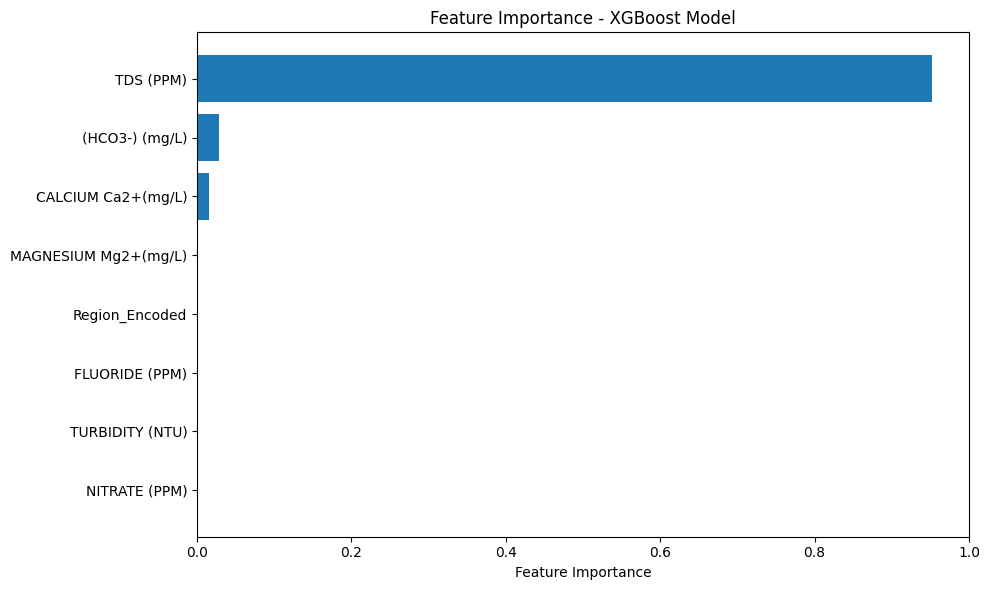

In [17]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(indices)),
    importances[indices]
)

plt.yticks(
    range(len(indices)),
    [feature_cols[i] for i in indices]
)

plt.xlabel("Feature Importance")
plt.title("Feature Importance - XGBoost Model")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Visualize Actual vs Predicted

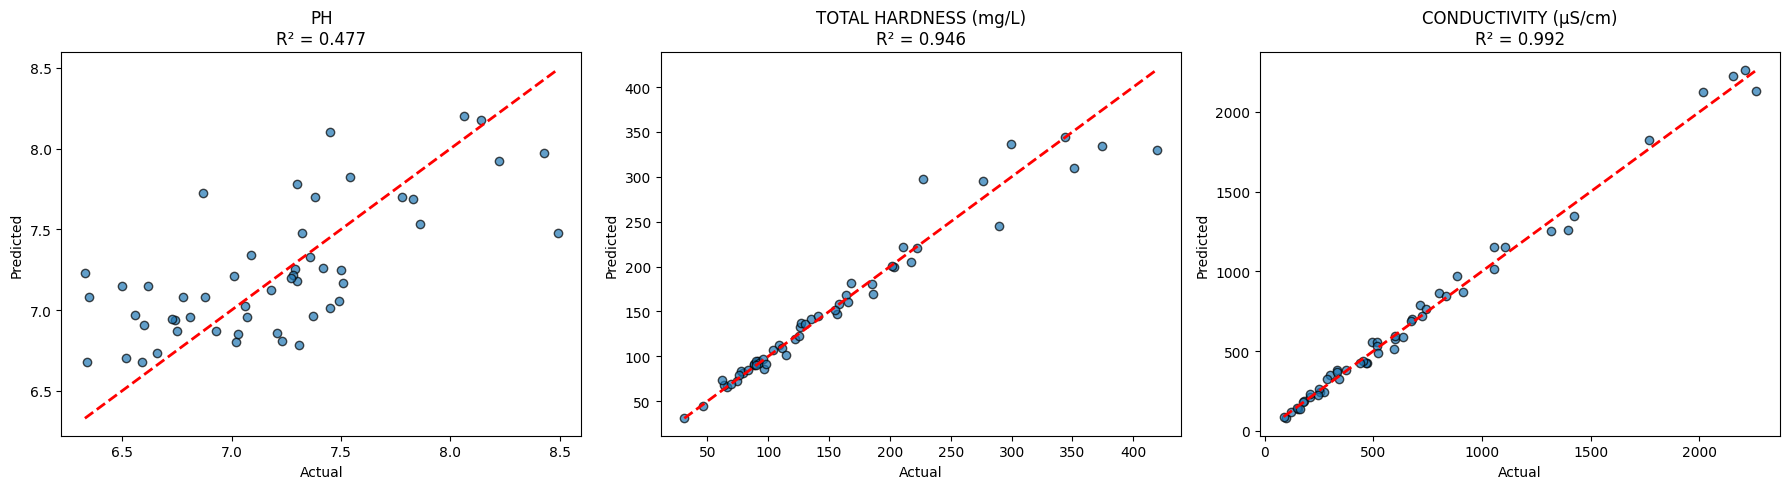

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(target_cols):
    axes[i].scatter(y_test_df.iloc[:, i], y_pred_df.iloc[:, i], alpha=0.7, edgecolor='k')
    axes[i].plot([y_test_df.iloc[:, i].min(), y_test_df.iloc[:, i].max()],
                 [y_test_df.iloc[:, i].min(), y_test_df.iloc[:, i].max()],
                 'r--', lw=2)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{col}\nR² = {r2_score(y_test_df.iloc[:, i], y_pred_df.iloc[:, i]):.3f}')

plt.tight_layout()
plt.show()

Predict New Sample (Example)

In [19]:
sample = X_test.iloc[[4]]
print("Sample features:")
print(sample)

prediction = model.predict(sample)
print("\nPredicted values:")
print(f"pH              : {prediction[0][0]:.2f}")
print(f"Total Hardness  : {prediction[0][1]:.2f} mg/L")
print(f"Conductivity    : {prediction[0][2]:.2f} µS/cm")

print("\nActual values:")
print(y_test.iloc[0])

Sample features:
     NITRATE (PPM)  FLUORIDE (PPM)  CALCIUM Ca2+(mg/L)  MAGNESIUM Mg2+(mg/L)  \
211           20.9            1.16              31.389                19.034   

     (HCO3-) (mg/L)  TDS (PPM)  TURBIDITY (NTU)  Region_Encoded  
211           118.3      101.4             2.54               7  

Predicted values:
pH              : 7.21
Total Hardness  : 147.14 mg/L
Conductivity    : 184.48 µS/cm

Actual values:
PH                          7.02
TOTAL HARDNESS (mg/L)     125.88
CONDUCTIVITY (µS/cm)     1395.80
Name: 30, dtype: float64


Function of Boundaries + Recommendation

In [20]:
def get_ph_recommendation(ph_value):
    """
    Inachukua predicted PH na kutoa:
    - Category (Acidic / Neutral / Basic)
    - Recommendation kwa kunywa
    - NOT RECOGNIZED kama PH iko nje ya range 0-14
    """

    # Check kama PH iko nje ya boundaries
    if ph_value < 0 or ph_value > 14:
        return {
            "Predicted_PH": round(ph_value, 2),
            "Category": "NOT RECOGNIZED",
            "Status": "Invalid PH Value",
            "Recommendation": "PH value must be between 0 and 14."
        }

    # Acidic
    if ph_value < 7:
        category = "ACIDIC"
        recommendation = (
            "NOT PREFERRED for drinking "
            "(Acidic water can be corrosive and may have metallic taste)"
        )
        status = "Not Safe / Not Preferred"

    # Neutral
    elif ph_value == 7:
        category = "NEUTRAL"
        recommendation = "PREFERRED for drinking (Balanced water)"
        status = "Safe / Preferred"

    # Basic / Alkaline
    else:
        category = "BASIC (Alkaline)"
        recommendation = (
            "Acceptable but may have bitter/soapy taste. "
            "Better if between 7.0 - 8.5"
        )
        status = "Acceptable (monitor)"

    return {
        "Predicted_PH": round(ph_value, 2),
        "Category": category,
        "Status": status,
        "Recommendation": recommendation
    }

Test recommendation Function

In [21]:

print(get_ph_recommendation(7))
print()

print(get_ph_recommendation(17))
print()

print(get_ph_recommendation(7.0))
print()

{'Predicted_PH': 7, 'Category': 'NEUTRAL', 'Status': 'Safe / Preferred', 'Recommendation': 'PREFERRED for drinking (Balanced water)'}

{'Predicted_PH': 17, 'Category': 'NOT RECOGNIZED', 'Status': 'Invalid PH Value', 'Recommendation': 'PH value must be between 0 and 14.'}

{'Predicted_PH': 7.0, 'Category': 'NEUTRAL', 'Status': 'Safe / Preferred', 'Recommendation': 'PREFERRED for drinking (Balanced water)'}




Predict + Give Recommendation (Real Sample)

In [22]:
def predict_new_water_sample(model, feature_columns, region_encoder):
    """
    Ingiza values mpya na upate PH + Recommendation
    """
    print("\nIngiza values za sample mpya:")

    # Mfano wa kuingiza
    data = {}
    for col in feature_columns:
        if col == "Region_Encoded":
            print("\nRegions zilizopo:")
            for name, code in zip(region_encoder.classes_, region_encoder.transform(region_encoder.classes_)):
                print(f"  {code} = {name}")
            value = int(input(f"Weka code ya Region: "))
        else:
            value = float(input(f"{col}: "))
        data[col] = value

    # Convert to DataFrame
    sample_df = pd.DataFrame([data], columns=feature_columns)

    # Predict
    predicted_ph = model.predict(sample_df)[0]
    result = get_ph_recommendation(predicted_ph)

    print("\n" + "="*60)
    print("MATOKEO YA SAMPLE MPYA")
    print("="*60)
    print(f"Predicted PH     : {result['Predicted_PH']}")
    print(f"Category         : {result['Category']}")
    print(f"Status           : {result['Status']}")
    print(f"Recommendation   : {result['Recommendation']}")
    print("="*60)

    return result

Save the Model (Optional)

In [23]:
import joblib

joblib.dump(model, 'tanzania_water_rf_model.pkl')
joblib.dump(le, 'region_label_encoder.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')

print("Model imehifadhiwa kama 'tanzania_water_rf_model.pkl'")

Model imehifadhiwa kama 'tanzania_water_rf_model.pkl'


WATER QUALITY PREDICTION INTERFACE

In [24]:
# ============================================================
# WATER QUALITY PREDICTION INTERFACE
# Connects directly to the existing trained XGBoost model
# ============================================================

# Install Gradio
!pip -q install gradio

import joblib
import pandas as pd
import gradio as gr


# ============================================================
# 1. LOAD EXISTING MODEL AND SUPPORT FILES
# ============================================================

model = joblib.load("tanzania_water_rf_model.pkl")
region_encoder = joblib.load("region_label_encoder.pkl")
feature_columns = joblib.load("feature_columns.pkl")

print("Model loaded successfully!")
print("Feature columns:")
print(feature_columns)


# ============================================================
# 2. PH RECOMMENDATION FUNCTION
# ============================================================

def get_ph_recommendation(ph_value):

    # Check PH boundaries
    if ph_value < 0 or ph_value > 14:
        return {
            "Predicted_PH": round(ph_value, 2),
            "Category": "NOT RECOGNIZED",
            "Status": "Invalid PH Value",
            "Recommendation": "PH value must be between 0 and 14."
        }

    # PH classification
    if ph_value < 6.5:
        category = "ACIDIC"
        status = "Not Safe / Not Preferred"
        recommendation = (
            "NOT PREFERRED for drinking "
            "(Acidic water can be corrosive and may have metallic taste)"
        )

    elif ph_value < 7.0:
        category = "SLIGHTLY ACIDIC"
        status = "Acceptable / Monitor"
        recommendation = (
            "Acceptable, but monitoring is recommended "
            "because the water is slightly acidic."
        )

    elif ph_value <= 8.5:
        category = "NEUTRAL"
        status = "Safe / Preferred"
        recommendation = (
            "PREFERRED for drinking "
            "(Balanced water)"
        )

    else:
        category = "ALKALINE"
        status = "Acceptable / Monitor"
        recommendation = (
            "Acceptable, but monitoring is recommended. "
            "Better if between 7.0 - 8.5."
        )

    return {
        "Predicted_PH": round(ph_value, 2),
        "Category": category,
        "Status": status,
        "Recommendation": recommendation
    }


# ============================================================
# 3. PREDICTION FUNCTION
# ============================================================

def predict_water_quality(
    nitrate,
    fluoride,
    calcium,
    magnesium,
    hco3,
    tds,
    turbidity,
    region
):

    try:

        # ----------------------------------------------------
        # Convert Region name to encoded value
        # ----------------------------------------------------
        region_encoded = region_encoder.transform([region])[0]

        # ----------------------------------------------------
        # Create input DataFrame
        # ----------------------------------------------------
        input_data = {
            "NITRATE (PPM)": nitrate,
            "FLUORIDE (PPM)": fluoride,
            "CALCIUM Ca2+(mg/L)": calcium,
            "MAGNESIUM Mg2+(mg/L)": magnesium,
            "(HCO3-) (mg/L)": hco3,
            "TDS (PPM)": tds,
            "TURBIDITY (NTU)": turbidity,
            "Region_Encoded": region_encoded
        }

        input_df = pd.DataFrame(
            [input_data],
            columns=feature_columns
        )

        # ----------------------------------------------------
        # Make prediction
        # ----------------------------------------------------
        prediction = model.predict(input_df)[0]

        # ----------------------------------------------------
        # Get predictions
        # ----------------------------------------------------
        predicted_ph = float(prediction[0])
        predicted_hardness = float(prediction[1])
        predicted_conductivity = float(prediction[2])

        # ----------------------------------------------------
        # PH recommendation
        # ----------------------------------------------------
        ph_result = get_ph_recommendation(predicted_ph)

        # ----------------------------------------------------
        # Return results
        # ----------------------------------------------------
        return (
            round(predicted_ph, 2),
            ph_result["Category"],
            ph_result["Status"],
            ph_result["Recommendation"],
            round(predicted_hardness, 2),
            round(predicted_conductivity, 2)
        )

    except Exception as e:

        return (
            None,
            "ERROR",
            "Prediction Failed",
            str(e),
            None,
            None
        )


# ============================================================
# 4. GET REGION LIST
# ============================================================

regions = list(region_encoder.classes_)


# ============================================================
# 5. CREATE GRADIO INTERFACE
# ============================================================

with gr.Blocks(title="Water Quality Prediction System") as demo:

    gr.Markdown(
        """
        # 💧 Water Quality Prediction System

        ### Predict PH, Total Hardness and Conductivity
        Enter the water parameters below and select the region.
        """
    )

    gr.Markdown("## 🔬 Input Water Parameters")

    with gr.Row():

        nitrate = gr.Number(
            label="Nitrate (PPM)",
            value=10
        )

        fluoride = gr.Number(
            label="Fluoride (PPM)",
            value=1
        )

    with gr.Row():

        calcium = gr.Number(
            label="Calcium Ca²⁺ (mg/L)",
            value=50
        )

        magnesium = gr.Number(
            label="Magnesium Mg²⁺ (mg/L)",
            value=20
        )

    with gr.Row():

        hco3 = gr.Number(
            label="HCO₃⁻ (mg/L)",
            value=100
        )

        tds = gr.Number(
            label="TDS (PPM)",
            value=500
        )

    with gr.Row():

        turbidity = gr.Number(
            label="Turbidity (NTU)",
            value=5
        )

        region = gr.Dropdown(
            choices=regions,
            label="Region / Zone",
            value=regions[0]
        )

    predict_button = gr.Button(
        "🔍 PREDICT WATER QUALITY",
        variant="primary"
    )

    gr.Markdown("## 📊 Prediction Results")

    with gr.Row():

        predicted_ph = gr.Number(
            label="Predicted PH"
        )

        ph_category = gr.Textbox(
            label="PH Category"
        )

        ph_status = gr.Textbox(
            label="PH Status"
        )

    ph_recommendation = gr.Textbox(
        label="PH Recommendation",
        lines=3
    )

    with gr.Row():

        predicted_hardness = gr.Number(
            label="Predicted Total Hardness (mg/L)"
        )

        predicted_conductivity = gr.Number(
            label="Predicted Conductivity (µS/cm)"
        )


    # --------------------------------------------------------
    # CONNECT BUTTON TO MODEL
    # --------------------------------------------------------

    predict_button.click(
        fn=predict_water_quality,

        inputs=[
            nitrate,
            fluoride,
            calcium,
            magnesium,
            hco3,
            tds,
            turbidity,
            region
        ],

        outputs=[
            predicted_ph,
            ph_category,
            ph_status,
            ph_recommendation,
            predicted_hardness,
            predicted_conductivity
        ]
    )


# ============================================================
# 6. LAUNCH INTERFACE
# ============================================================

demo.launch(share=True)

Model loaded successfully!
Feature columns:
['NITRATE (PPM)', 'FLUORIDE (PPM)', 'CALCIUM Ca2+(mg/L)', 'MAGNESIUM Mg2+(mg/L)', '(HCO3-) (mg/L)', 'TDS (PPM)', 'TURBIDITY (NTU)', 'Region_Encoded']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9aa8b10dacc3f2e309.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
